# GNN — 1 Lepton 2 Taus (Run 2 + Run 3)

Graph-neural-network counterpart to `DNN.ipynb`'s flat-feature MLP, on the
same 1l2tau data (`Evie/PPSSP_2026/1l2tau/run2` and `.../run3`), same
preselection, same leakage-free feature policy, and the same deterministic
80/10/10 train/val/test split - so results are directly comparable.

**Representation change.** The MLP concatenates every event into one flat
feature vector (kinematics + hand-engineered pairwise variables like `dR_*`,
`m_*`, `HT_*`). This notebook instead represents each event as a small graph:
one node per reconstructed physics object (lepton, tau1, tau2, jet1, jet2,
MET), each carrying only its own kinematics, with a fully-connected edge set
within the event. The hand-engineered pairwise/aggregate variables are
deliberately **not** given to the model — the point of the GNN is to see how
much of that relational information (angular separations, invariant masses,
combined momenta) message passing can recover on its own from raw 4-vectors.

**Scope.** This mirrors the core of the MLP pipeline — data loading, graph
construction, model, training with early stopping, ROC/AUC evaluation, and a
single held-out test evaluation — for Run 2 first, then a separate Run 3
downstream section further down (same `_run3`-suffixed-variable convention
as `DNN.ipynb`, reusing the Run 2 section's functions/classes/schema
unchanged). Permutation importance and correlation pruning are feature-level
diagnostics that don't map cleanly onto graph nodes; permutation importance
is adapted below (ranking the ~23 raw per-object columns instead of ~80 flat
features), but correlation pruning, the hyperparameter grid search, and the
Combined Run2+Run3 track are left out to keep this notebook focused — see
`DNN.ipynb` for those.

## Libraries

In [ ]:
import os

# Must be set BEFORE CUDA/cuBLAS initializes for deterministic cuBLAS matmul.
# If this kernel already has CUDA initialized (e.g. you've run cells before
# adding this), these two env vars won't take effect until you RESTART THE
# KERNEL.

os.environ["PYTHONHASHSEED"] = "42"
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

# torch and uproot (via numpy) can each bundle their own OpenMP runtime;
# loading both in one process aborts the kernel on some platforms
# ("OMP: Error #15 ... libomp.dylib already initialized") unless this is
# set before either is imported.
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")

import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
import uproot
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve

from torch_geometric.nn import GATv2Conv, global_mean_pool, global_max_pool

RANDOM_STATE = 42

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def set_seed(seed: int = RANDOM_STATE):

    """
    Full determinism, not just seeding: also pins cuDNN to deterministic
    kernels, disables its autotuner, and asks torch to error out (rather than
    silently fall back) on any op without a deterministic implementation.
    Same convention as DNN.ipynb's set_seed, so re-seeded runs here are
    reproducible the same way. Determinism is only guaranteed on the SAME
    machine / CUDA / torch version - it is not portable across hardware or
    library versions.
    """

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms(True)


set_seed(RANDOM_STATE)

print(f"Using device: {DEVICE}")

In [ ]:
# ---------------------------------------------------------------------------
# Paths - 1 lepton + 2 taus, Run 2 and Run 3 (same source files as
# DNN.ipynb / the Final_Notebooks/1L2Tau_Master_Pipeline.ipynb, so results
# are comparable).
# ---------------------------------------------------------------------------

BASE_DIR_RUN2 = Path("PPSSP_2026/1l2tau/run2")
BASE_DIR_RUN3 = Path("PPSSP_2026/1l2tau/run3")

# Active run used by downstream cells by default (Run 2 first pass below;
# switched to Run 3 in the separate downstream section further down).
BASE_DIR = BASE_DIR_RUN2
ACTIVE_RUN = "Run 2"
TREE_NAME = "AnalysisMiniTree"

# ---------------------------------------------------------------------------
# Preselection (see repo README.md, "1 Lepton 2 Taus")
# ---------------------------------------------------------------------------

PRESELECTION = "(n_b_jet == 0) & (n_jet >= 2)"

# ---------------------------------------------------------------------------
# Processes: filename + label (1 = signal, 0 = background)
# ---------------------------------------------------------------------------

FILES = {
    "signal_ggF": ("signal_ggF.root", 1),
    "signal_VBF": ("signal_VBF.root", 1),
    "Diboson":    ("diboson.root",    0),
    "Zjets":      ("Zjets.root",      0),
    "Wjets":      ("Wjets.root",      0),
    "ttbar":      ("ttbar.root",      0),
    "tops":       ("tops.root",       0),
    "SingleH":    ("singleH.root",    0),
    "Vgamma":     ("Vgamma.root",     0),
    "VVV":        ("VVV.root",        0),
}

WEIGHT_PARTS = ["weight", "weights"]  # raw branches; w_phys = their product

# ---------------------------------------------------------------------------
# Leakage-free feature-selection policy - IDENTICAL to DNN.ipynb / the
# XGBoost master pipeline, so this notebook builds graph nodes only out of
# branches the other models are also allowed to see.
# ---------------------------------------------------------------------------

BLOCK_SUBSTR = ["weight", "effsf", "_ff", "truth", "istrue", "fake", "anti",
                "dsid", "eventnumber", "_RNNTight", "_isOS", "_d0sig"]
BLOCK_EXACT = {
    "n_b_jet", "pass1l2tau", "hhml_subchannelflavor",
    "tau1_RNNJetScoreSigTrans", "tau2_RNNJetScoreSigTrans",
    "pair_isOStaus", "pair_isOSleptau", "tau2_baseline_RNNTight", "l1_d0sig", "tau1_charge", "tau2_charge", "mZ_veto", "tau1_decayMode", "tau2_decayMode", "tau1_nprong", "tau2_nprong"
}

BLOCK_EXACT_LOWER = {b.lower() for b in BLOCK_EXACT}


def is_feature(branch: str) -> bool:

    """True if `branch` is safe to use as a training feature (see policy above)."""

    lb = branch.lower()
    return lb not in BLOCK_EXACT_LOWER and not any(s.lower() in lb for s in BLOCK_SUBSTR)

## Data Loading Helpers

Identical to `DNN.ipynb`'s loaders - same discovery, same preselection, same
sentinel-to-NaN cleaning - so `data`/`features` here are byte-identical to
the MLP notebook's Run 2 `data_run2`/`features_run2`.

In [ ]:
def discover_common_features(base_dir, files=FILES, tree_name=TREE_NAME):

    """
    Branches common to EVERY process file in `base_dir`, filtered through`is_feature`.
    """

    common = None

    for fname, _ in files.values():
        keys = set(uproot.open({str(Path(base_dir) / fname): tree_name}).keys())
        common = keys if common is None else common & keys

    features = sorted(b for b in common if is_feature(b))

    print(f"{len(features)} candidate features (common to all {len(files)} processes, leakage-free)")

    return features


def load_run_data(base_dir, features, files=FILES, weight_parts=WEIGHT_PARTS,
                   preselection=PRESELECTION, tree_name=TREE_NAME, verbose=True):

    """
    Read every process file under `base_dir`, apply the preselection at
    read time, and concatenate into one DataFrame with bookkeeping columns:
      - w_phys  : physical event weight = weight * weights
      - label   : 1 = signal, 0 = background
      - process : originating process name
    """

    base_dir = Path(base_dir)
    dfs = []

    for proc, (fname, label) in files.items():

        tree = uproot.open({str(base_dir / fname): tree_name})
        df = tree.arrays(features + weight_parts, cut=preselection, library="pd")
        df["w_phys"] =  df["weights"] * df["weight"]
        df["label"] = label
        df["process"] = proc
        dfs.append(df)

        if verbose:
            print(f"{proc:12s}: {len(df):>8d} events after preselection")

    return pd.concat(dfs, ignore_index=True)


def clean_data(data, features, verbose=True):

    """
    Post-concat cleaning: drop constant/empty features, then mask sentinel
    values (< -100, e.g. -999) to NaN. Returns (cleaned_data, updated_features);
    operates on a copy, does not mutate the input DataFrame.
    """

    data = data.copy()
    nun = data[features].nunique()
    const = nun[nun <= 1].index.tolist()
    features = [f for f in features if f not in const]
    data = data.drop(columns=const)

    if verbose:
        print(f"Dropped {len(const)} constant/empty features:\n  {sorted(const)}")

    for f in features:
        m = data[f] < -100
        if m.any():
            if verbose:
                print(f"  sentinel -> NaN: {f} ({m.mean():.1%})")
            data[f] = data[f].mask(m)

    if verbose:
        print(f"\n{len(features)} final features")
        print(f"Total: {len(data)} events | signal = {(data.label==1).sum()} | "
              f"background = {(data.label==0).sum()}")
        print(f"Yield (w_phys): signal = {data.loc[data.label==1,'w_phys'].sum():.2f} | "
              f"background = {data.loc[data.label==0,'w_phys'].sum():.2f}")
    return data, features

## Load Run 2 Data

In [ ]:
candidate_features = discover_common_features(BASE_DIR_RUN2)
data = load_run_data(BASE_DIR_RUN2, candidate_features)
data, features = clean_data(data, candidate_features)

print(f"\nLoaded {len(data)} events | {len(features)} leakage-free features available")

## Sentinel Audit (-1)

Same diagnostic as `DNN.ipynb`: `clean_data` only masks `< -100` sentinels
(e.g. `-999`) to NaN. Some ATLAS branches instead default to exactly `-1`
for "undefined", which is also a perfectly valid value for other branches
(e.g. charges) - so it must **not** be blanket-masked. Kept empty here to
match the MLP notebook's audited conclusion (no genuine `-1` sentinels among
the leakage-free features for this dataset); re-run and inspect
`neg1_df` if the upstream ntuples change.

In [ ]:
NEG1_SENTINEL_FEATURES = set()

neg1_rows = []
for f in features:
    vals = data[f]
    frac_neg1 = (vals == -1).mean()
    if frac_neg1 == 0:
        continue
    above = vals[vals > -1]
    gap = (above.min() - (-1)) if len(above) else np.nan
    neg1_rows.append({"feature": f, "frac_exactly_-1": frac_neg1, "gap_to_next_value_above": gap})

neg1_df = pd.DataFrame(neg1_rows).sort_values("frac_exactly_-1", ascending=False)
print(f"{len(neg1_df)} / {len(features)} features have at least one row exactly equal to -1:")
print(neg1_df.to_string(index=False))

for f in NEG1_SENTINEL_FEATURES:
    data[f] = data[f].mask(data[f] == -1)

if NEG1_SENTINEL_FEATURES:
    print(f"\nMasked -1 -> NaN for: {sorted(NEG1_SENTINEL_FEATURES)}")
else:
    print("\nNEG1_SENTINEL_FEATURES is empty - no -1 values masked.")

## Train/Validation/Test Split

Same deterministic two-stage stratified **80/10/10** split (`make_3way_split`)
as `DNN.ipynb`, on the same `data` - so TEST here is the same set of events as
the MLP notebook's TEST, cross-checked against its persisted partition.
TEST is held out from everything below (imputation, scaling, early stopping)
until the single "Held-Out Test Evaluation" cell at the end.

In [ ]:
def make_fit_weights(labels, abs_weights):

    """
    Balance signal/background total weight and normalize the mean weight
    to 1. `abs_weights` must already be non-negative (Sherpa weights can be
    negative).
    """

    labels = np.asarray(labels)

    fit_weights = np.asarray(abs_weights, dtype=float).copy()
    sum_signal = fit_weights[labels == 1].sum()
    sum_background = fit_weights[labels == 0].sum()
    fit_weights[labels == 1] *= sum_background / sum_signal
    fit_weights *= len(fit_weights) / fit_weights.sum()

    return fit_weights


def make_3way_split(data, test_size=0.10, val_size=0.10, seed=RANDOM_STATE, extra_stratify_col=None):

    """
    Deterministic two-stage stratified 80/10/10 train/val/test split -
    IDENTICAL logic (same seed, same stratify) to DNN.ipynb's
    make_3way_split, so both notebooks land on the same partitions whenever
    `data` is built identically (same FILES order -> concat -> clean_data).
    """

    def _strata(df):
        if extra_stratify_col is not None:
            return df["label"].astype(str) + "_" + df[extra_stratify_col].astype(str)
        return df["label"]

    trainval_df, test_df = train_test_split(data, test_size=test_size, random_state=seed, stratify=_strata(data))

    val_frac_of_remaining = val_size / (1 - test_size)
    train_df, val_df = train_test_split(
        trainval_df, test_size=val_frac_of_remaining, random_state=seed, stratify=_strata(trainval_df)
    )

    for name, df in (("Train", train_df), ("Val", val_df), ("Test", test_df)):
        sig_n, bkg_n = int((df.label == 1).sum()), int((df.label == 0).sum())
        sig_y = df.loc[df.label == 1, "w_phys"].sum()
        bkg_y = df.loc[df.label == 0, "w_phys"].sum()
        print(f"{name:5s}: {len(df):>8d} events | signal = {sig_n:>7d} (yield={sig_y:>10.2f}) | "
              f"background = {bkg_n:>7d} (yield={bkg_y:>10.2f}) | "
              f"signal weight scale factor = {bkg_y / sig_y:.1f}")

    return train_df, val_df, test_df


def assert_same_test_partition(test_df, path):

    """
    Cross-notebook guard: if a test partition already exists on disk at
    `path` (written by DNN.ipynb / the master pipeline reading this same
    BASE_DIR), verify this notebook's freshly-computed `test_df` is
    equal to it on their shared columns.
    """

    path = Path(path)
    if not path.exists():
        print(f"  (no prior test partition at {path} yet - nothing to cross-check)")
        return

    prior_df = uproot.open({str(path): "tree"}).arrays(library="pd")
    cols = sorted((set(test_df.columns) & set(prior_df.columns)) - {"run"})
    a = test_df[cols].sort_values(cols).reset_index(drop=True)
    b = prior_df[cols].sort_values(cols).reset_index(drop=True)

    pd.testing.assert_frame_equal(a, b, check_exact=False, rtol=1e-5, atol=1e-8, check_dtype=False)
    print(f"  cross-check OK: {path} test partition matches on {len(cols)} shared columns ({len(test_df)} rows)")


train_df, val_df, test_df = make_3way_split(data)

SPLIT_DIR_RUN2 = BASE_DIR_RUN2 / "splits"
assert_same_test_partition(test_df, SPLIT_DIR_RUN2 / "test.root")

## Object / Node Schema

Six nodes per event, one per reconstructed object, using only branches that
survive the leakage-free `is_feature` policy above and that `clean_data`
didn't drop as constant (checked against this dataset: the tau `_base_id` /
`_passOR` / `_besline_RNNMedium_eleid` flags are constant post-preselection
and so aren't available - only kinematics remain for tau1/tau2).

| node   | source prefix | fields                          |
|--------|---------------|----------------------------------|
| lepton | `l1_`         | pt, eta, phi, e, charge, pdg (-> is_electron) |
| tau1   | `tau1_`       | pt, eta, phi                     |
| tau2   | `tau2_`       | pt, eta, phi                     |
| jet1   | `j1_`         | pt, eta, phi, e                  |
| jet2   | `j2_`         | pt, eta, phi, e                  |
| MET    | `met_`        | met (-> pt slot), phi, sumet (-> e slot) |

Each node's feature vector is `[pt, eta, sin(phi), cos(phi), e, charge,
is_electron, is_lepton, is_tau, is_jet, is_met]` (11 dims) - fields that
don't apply to an object (e.g. tau charge, blocked as leakage; MET eta,
undefined) are zero-filled, and the 4-way type one-hot lets the (shared)
graph-conv weights tell object roles apart. `phi` is encoded as
`(sin, cos)` rather than a raw scaled scalar so its circular topology
(`-pi` and `+pi` are the same angle) isn't broken by standard scaling.

In [ ]:
OBJECT_COLUMNS = {
    "lepton": {"pt": "l1_pt",   "eta": "l1_eta",   "phi": "l1_phi",   "e": "l1_e", "charge": "l1_charge", "pdg": "l1_pdg"},
    "tau1":   {"pt": "tau1_pt", "eta": "tau1_eta", "phi": "tau1_phi"},
    "tau2":   {"pt": "tau2_pt", "eta": "tau2_eta", "phi": "tau2_phi"},
    "jet1":   {"pt": "j1_pt",   "eta": "j1_eta",   "phi": "j1_phi",   "e": "j1_e"},
    "jet2":   {"pt": "j2_pt",   "eta": "j2_eta",   "phi": "j2_phi",   "e": "j2_e"},
    "met":    {"pt": "met_met", "phi": "met_phi",  "e": "met_sumet"},
}
NODE_ORDER = ["lepton", "tau1", "tau2", "jet1", "jet2", "met"]
NODE_TYPE = {"lepton": "lepton", "tau1": "tau", "tau2": "tau", "jet1": "jet", "jet2": "jet", "met": "met"}
TYPE_LIST = ["lepton", "tau", "jet", "met"]
N_NODES = len(NODE_ORDER)
N_NODE_FEATURES = 7 + len(TYPE_LIST)  # pt, eta, sin(phi), cos(phi), e, charge, is_electron + type one-hot

REQUIRED_OBJECT_COLUMNS = sorted({c for cols in OBJECT_COLUMNS.values() for c in cols.values()})
missing = [c for c in REQUIRED_OBJECT_COLUMNS if c not in features]
assert not missing, f"Node schema references columns dropped by clean_data / the leakage policy: {missing}"

# Continuous columns (imputed + standard-scaled, fit on TRAIN only). phi is
# handled separately via sin/cos; charge and pdg-derived is_electron are
# left unscaled (0/1-ish flags - scaling would just relabel them).
CONTINUOUS_NODE_COLS = sorted({
    c for cols in OBJECT_COLUMNS.values() for k, c in cols.items() if k in ("pt", "eta", "e")
})

print(f"{N_NODES} nodes/event x {N_NODE_FEATURES} features/node")
print(f"{len(CONTINUOUS_NODE_COLS)} continuous columns to impute + scale: {CONTINUOUS_NODE_COLS}")

# Fully-connected edge set - identical topology for every event (n_jet >= 2
# in the preselection guarantees all 6 slots are always populated), so it's
# built once and shared across every graph.
EDGE_INDEX = torch.tensor(
    [[i, j] for i in range(N_NODES) for j in range(N_NODES) if i != j],
    dtype=torch.long,
).t().contiguous().to(DEVICE)

# ---- Batched edge_index / batch-vector helpers -----------------------------
# Every event shares the EXACT SAME graph topology, so a whole batch's
# disjoint-union edge_index and node->graph `batch` vector can be built with
# plain vectorized tensor ops (broadcasting/repeat), never a Python loop over
# individual graphs - this is what lets training skip PyG's DataLoader
# collation entirely (see the dataset-building / run_epoch cells below).
# Cached per batch size since the same size is reused every batch/epoch.
_edge_index_cache = {}
_batch_vector_cache = {}


def get_batched_edge_index(batch_size):

    """Disjoint-union `edge_index` for `batch_size` copies of EDGE_INDEX,
    node indices offset by i * N_NODES per graph i."""

    if batch_size not in _edge_index_cache:
        offsets = torch.arange(batch_size, device=DEVICE).repeat_interleave(EDGE_INDEX.shape[1]) * N_NODES
        _edge_index_cache[batch_size] = EDGE_INDEX.repeat(1, batch_size) + offsets
    return _edge_index_cache[batch_size]


def get_batch_vector(batch_size):

    """`batch` vector (which graph each of the batch_size * N_NODES rows of
    a flattened node tensor belongs to), matching PyG's `Batch.batch` convention."""

    if batch_size not in _batch_vector_cache:
        _batch_vector_cache[batch_size] = torch.arange(batch_size, device=DEVICE).repeat_interleave(N_NODES)
    return _batch_vector_cache[batch_size]


# ---- Median imputation (fit on TRAIN only), then standard scaling on the
# continuous columns only (fit on TRAIN only). Mirrors DNN.ipynb's
# imputation/scaling convention, restricted to the columns the graph nodes
# actually use.
train_medians = train_df[REQUIRED_OBJECT_COLUMNS].median()

train_imp = train_df[REQUIRED_OBJECT_COLUMNS].fillna(train_medians)
val_imp = val_df[REQUIRED_OBJECT_COLUMNS].fillna(train_medians)
test_imp = test_df[REQUIRED_OBJECT_COLUMNS].fillna(train_medians)

scaler = StandardScaler()
train_scaled = train_imp.copy()
val_scaled = val_imp.copy()
test_scaled = test_imp.copy()
train_scaled[CONTINUOUS_NODE_COLS] = scaler.fit_transform(train_imp[CONTINUOUS_NODE_COLS])
val_scaled[CONTINUOUS_NODE_COLS] = scaler.transform(val_imp[CONTINUOUS_NODE_COLS])
test_scaled[CONTINUOUS_NODE_COLS] = scaler.transform(test_imp[CONTINUOUS_NODE_COLS])

assert np.isfinite(train_scaled.to_numpy()).all(), "NaN/inf reached the model input (train)"
assert np.isfinite(val_scaled.to_numpy()).all(), "NaN/inf reached the model input (val)"
assert np.isfinite(test_scaled.to_numpy()).all(), "NaN/inf reached the model input (test)"

print("Imputation + scaling done (fit on train only).")

## Graph Construction

Vectorized build of the `(n_events, N_NODES, N_NODE_FEATURES)` node-feature
tensor for each split, then wrapped one `torch_geometric.data.Data` object
per event (all sharing the same precomputed `EDGE_INDEX`).

In [ ]:
def stack_node_features(df_scaled, df_imp):

    """
    Vectorized construction of the (n_events, N_NODES, N_NODE_FEATURES) node
    tensor. `df_scaled` supplies pt/eta/e (imputed + standard-scaled);
    `df_imp` supplies phi/charge/pdg (imputed but NOT scaled - phi goes
    through sin/cos, charge/pdg are categorical-ish and left raw).
    """

    n = len(df_scaled)
    node_arrays = []

    for name in NODE_ORDER:
        cols = OBJECT_COLUMNS[name]

        pt = df_scaled[cols["pt"]].to_numpy(dtype=np.float32)
        eta = df_scaled[cols["eta"]].to_numpy(dtype=np.float32) if "eta" in cols else np.zeros(n, dtype=np.float32)
        phi = df_imp[cols["phi"]].to_numpy(dtype=np.float32)
        e = df_scaled[cols["e"]].to_numpy(dtype=np.float32) if "e" in cols else np.zeros(n, dtype=np.float32)
        charge = df_imp[cols["charge"]].to_numpy(dtype=np.float32) if "charge" in cols else np.zeros(n, dtype=np.float32)
        is_electron = (
            (np.abs(df_imp[cols["pdg"]].to_numpy()) == 11).astype(np.float32)
            if "pdg" in cols else np.zeros(n, dtype=np.float32)
        )
        type_onehot = np.tile(
            np.array([float(NODE_TYPE[name] == t) for t in TYPE_LIST], dtype=np.float32), (n, 1)
        )

        node_arrays.append(np.column_stack(
            [pt, eta, np.sin(phi), np.cos(phi), e, charge, is_electron, type_onehot]
        ))

    return np.stack(node_arrays, axis=1)  # (n, N_NODES, N_NODE_FEATURES)


def build_graph_tensors(df_scaled, df_imp, df_raw, fit_weights=None):

    """
    Vectorized construction of GPU-resident tensors for one split: `x`
    (n_events, N_NODES, N_NODE_FEATURES), `y` (n_events,), `w_fit` (training
    weights, or None), and `w_abs` (plain |w_phys|, always). Replaces the
    old per-event list-of-`Data`-objects + PyG `DataLoader` approach: since
    every event shares the EXACT SAME graph topology (`EDGE_INDEX`/`N_NODES`
    are fixed), there's no need for PyG's dynamic-graph collation machinery
    at all - that per-batch Python-level `Batch.from_data_list` loop was the
    actual training bottleneck, not model compute. If `fit_weights` is given
    (class-balanced + mean-normalized training weights), `w_fit` holds those
    (paired with `w_abs` for eval-mode metrics on the same split); otherwise
    `w_fit` is None and only `w_abs` is meaningful (the val/test convention).
    """

    x = torch.from_numpy(stack_node_features(df_scaled, df_imp)).to(DEVICE)
    y = torch.from_numpy(df_raw["label"].to_numpy(dtype=np.float32)).to(DEVICE)
    w_abs = torch.from_numpy(np.abs(df_raw["w_phys"].to_numpy(dtype=np.float32))).to(DEVICE)
    w_fit = torch.from_numpy(fit_weights.astype(np.float32)).to(DEVICE) if fit_weights is not None else None

    return x, y, w_fit, w_abs


w_train_fit = make_fit_weights(train_df["label"].to_numpy(), np.abs(train_df["w_phys"].to_numpy()))

X_train, y_train, w_train_fit_t, w_train_eval_t = build_graph_tensors(train_scaled, train_imp, train_df, fit_weights=w_train_fit)
X_val, y_val_labels, _, w_val_abs = build_graph_tensors(val_scaled, val_imp, val_df)
X_test, y_test_labels, _, w_test_abs_t = build_graph_tensors(test_scaled, test_imp, test_df)

print(f"Built {X_train.shape[0]} train / {X_val.shape[0]} val / {X_test.shape[0]} test graphs (GPU-resident tensors)")
print(f"Node tensor shape per split: (n_events, {N_NODES}, {N_NODE_FEATURES})")

## GNN Model

Two `GATv2Conv` message-passing layers (attention over the fully-connected
neighborhood learns which object pairs matter per event, the relational
analogue of the MLP's hand-picked `dR_*`/`m_*` features), then
mean+max graph-level pooling, then a small MLP head - same dropout +
single-logit-output convention as `DNN.ipynb`'s `SimpleMLP`.

In [ ]:
BATCH_SIZE = 8192
DEFAULT_HIDDEN_CHANNELS = 64
DEFAULT_DROPOUT = 0.3


class ObjectGNN(nn.Module):

    """
    Object-level graph classifier: 2x GATv2Conv, mean+max pooling, MLP head,
    single output logit (paired with BCEWithLogitsLoss for numerical
    stability, same convention as DNN.ipynb's SimpleMLP).
    """

    def __init__(self, in_channels, hidden_channels=DEFAULT_HIDDEN_CHANNELS, dropout=DEFAULT_DROPOUT):

        super().__init__()
        self.conv1 = GATv2Conv(in_channels, hidden_channels)
        self.conv2 = GATv2Conv(hidden_channels, hidden_channels)
        self.dropout = dropout
        self.head = nn.Sequential(
            nn.Linear(hidden_channels * 2, hidden_channels), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden_channels, hidden_channels // 2), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden_channels // 2, 1),
        )

    def forward(self, x, edge_index, batch):
        x = F.relu(self.conv1(x, edge_index))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.relu(self.conv2(x, edge_index))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = torch.cat([global_mean_pool(x, batch), global_max_pool(x, batch)], dim=1)
        return self.head(x).squeeze(-1)


def build_model(hidden_channels=DEFAULT_HIDDEN_CHANNELS, dropout=DEFAULT_DROPOUT, in_channels=None):

    """Factory so training/hyperparameter code can build a fresh model per trial."""

    if in_channels is None:
        in_channels = N_NODE_FEATURES
    return ObjectGNN(in_channels=in_channels, hidden_channels=hidden_channels, dropout=dropout).to(DEVICE)


model = build_model()
print(model)

## Training Loop

Weighted binary cross-entropy, Adam optimizer, early stopping on weighted
validation AUC - same convention as `DNN.ipynb`'s `train_model`. Every epoch
also runs an eval-mode pass over the training graphs (dropout off, plain
`|w_phys|` weights via `w_eval`) so the logged `train_auc_eval`/`val_auc`
pair is directly comparable (the dropout-on `train_auc` used for the
gradient step is not).

In [ ]:
N_EPOCHS = 20
PATIENCE = 10
LEARNING_RATE = 1e-3


def run_epoch(model, X, y, w, criterion, optimizer, train, batch_size=BATCH_SIZE):

    """
    One pass over (X, y, w) in `batch_size`-sized chunks, optionally taking
    a gradient step. Batches via GPU-side tensor indexing (`torch.randperm`
    for shuffling on the train pass) instead of a PyG `DataLoader`, and the
    batched `edge_index`/`batch` vector come from the cached
    `get_batched_edge_index`/`get_batch_vector` helpers (vectorized, no
    per-graph Python loop). Only syncs to CPU ONCE at the end of the whole
    epoch (`.cpu().numpy()` below), not per batch - avoids both the CPU-bound
    per-batch graph collation AND the CUDA-sync overhead of the old
    DataLoader-based loop (each `.item()`/`.cpu()` call forces a full sync).
    """

    model.train(train)
    n = X.shape[0]
    order = torch.randperm(n, device=DEVICE) if train else torch.arange(n, device=DEVICE)

    total_loss = torch.zeros((), device=DEVICE)
    total_weight = torch.zeros((), device=DEVICE)
    all_labels, all_probs, all_weights = [], [], []

    with torch.set_grad_enabled(train):
        for start in range(0, n, batch_size):
            idx = order[start:start + batch_size]
            b = idx.shape[0]

            bx = X[idx].reshape(b * N_NODES, N_NODE_FEATURES)
            by = y[idx]
            bw = w[idx]

            logits = model(bx, get_batched_edge_index(b), get_batch_vector(b))
            loss = (criterion(logits, by) * bw).sum() / bw.sum()

            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            bw_sum = bw.sum().detach()
            total_loss += loss.detach() * bw_sum
            total_weight += bw_sum
            all_labels.append(by.detach())
            all_probs.append(torch.sigmoid(logits).detach())
            all_weights.append(bw.detach())

    labels = torch.cat(all_labels).cpu().numpy()
    probs = torch.cat(all_probs).cpu().numpy()
    weights = torch.cat(all_weights).cpu().numpy()
    auc = roc_auc_score(labels, probs, sample_weight=weights)

    return (total_loss / total_weight).item(), auc


def score_dataset(model, X, batch_size=BATCH_SIZE):

    """
    Batched inference over `X` (n_events, N_NODES, N_NODE_FEATURES),
    returning sigmoid probabilities as a 1-D GPU tensor. Reused by the
    val/test evaluation cells below instead of a PyG DataLoader loop.
    """

    model.eval()
    all_p = []
    with torch.no_grad():
        for start in range(0, X.shape[0], batch_size):
            bx = X[start:start + batch_size]
            b = bx.shape[0]
            logits = model(bx.reshape(b * N_NODES, N_NODE_FEATURES), get_batched_edge_index(b), get_batch_vector(b))
            all_p.append(torch.sigmoid(logits))
    return torch.cat(all_p)


def train_model(hidden_channels=DEFAULT_HIDDEN_CHANNELS, dropout=DEFAULT_DROPOUT, lr=LEARNING_RATE,
                 n_epochs=N_EPOCHS, patience=PATIENCE, verbose=True,
                 X_train_data=None, y_train_data=None, w_train_fit_data=None, w_train_eval_data=None,
                 X_val_data=None, y_val_data=None, w_val_data=None):

    """
    Build a fresh ObjectGNN and train it with early stopping on weighted
    validation AUC. Returns (model, history, best_val_auc, best_train_auc,
    best_train_auc_eval) - `model` already has the best-epoch weights
    loaded, and the two train_auc numbers are read off that SAME epoch.
    """

    X_train_data = X_train if X_train_data is None else X_train_data
    y_train_data = y_train if y_train_data is None else y_train_data
    w_train_fit_data = w_train_fit_t if w_train_fit_data is None else w_train_fit_data
    w_train_eval_data = w_train_eval_t if w_train_eval_data is None else w_train_eval_data
    X_val_data = X_val if X_val_data is None else X_val_data
    y_val_data = y_val_labels if y_val_data is None else y_val_data
    w_val_data = w_val_abs if w_val_data is None else w_val_data

    trial_model = build_model(hidden_channels=hidden_channels, dropout=dropout)
    criterion = nn.BCEWithLogitsLoss(reduction="none")
    optimizer = torch.optim.Adam(trial_model.parameters(), lr=lr)

    history = {"train_loss": [], "val_loss": [], "train_auc": [], "val_auc": [],
               "train_loss_eval": [], "train_auc_eval": []}
    best_val_auc, best_train_auc, best_train_auc_eval = -np.inf, None, None
    best_state, epochs_no_improve = None, 0

    for epoch in range(1, n_epochs + 1):

        train_loss, train_auc = run_epoch(trial_model, X_train_data, y_train_data, w_train_fit_data, criterion, optimizer, train=True)
        train_loss_eval, train_auc_eval = run_epoch(trial_model, X_train_data, y_train_data, w_train_eval_data, criterion, optimizer, train=False)
        val_loss, val_auc = run_epoch(trial_model, X_val_data, y_val_data, w_val_data, criterion, optimizer, train=False)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_auc"].append(train_auc)
        history["val_auc"].append(val_auc)
        history["train_loss_eval"].append(train_loss_eval)
        history["train_auc_eval"].append(train_auc_eval)

        if verbose:
            print(f"Epoch {epoch:3d} | train_loss={train_loss:.4f} val_loss={val_loss:.4f} "
                  f"| train_auc={train_auc:.4f} train_auc_eval={train_auc_eval:.4f} val_auc={val_auc:.4f}")

        if val_auc > best_val_auc:
            best_val_auc, best_train_auc, best_train_auc_eval = val_auc, train_auc, train_auc_eval
            best_state, epochs_no_improve = {k: v.clone() for k, v in trial_model.state_dict().items()}, 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                if verbose:
                    print(f"Early stopping at epoch {epoch} (best val_auc={best_val_auc:.4f})")
                break

    trial_model.load_state_dict(best_state)
    return trial_model, history, best_val_auc, best_train_auc, best_train_auc_eval

In [ ]:
model, history, best_val_auc, best_train_auc, best_train_auc_eval = train_model()

print(f"\nBest val_auc = {best_val_auc:.4f} | train_auc (dropout on) = {best_train_auc:.4f} "
      f"| train_auc_eval (dropout off, comparable) = {best_train_auc_eval:.4f}")

## Evaluation

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(history["train_loss"], label="train (dropout on)", color="tab:blue", alpha=0.5)
axes[0].plot(history["train_loss_eval"], label="train (dropout off, comparable)", color="tab:blue")
axes[0].plot(history["val_loss"], label="val", color="tab:orange")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("weighted BCE loss")
axes[0].set_title("Loss")
axes[0].legend()

axes[1].plot(history["train_auc"], label="train (dropout on)", color="tab:blue", alpha=0.5)
axes[1].plot(history["train_auc_eval"], label="train (dropout off, comparable)", color="tab:blue")
axes[1].plot(history["val_auc"], label="val", color="tab:orange")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("weighted AUC")
axes[1].set_title("AUC")
axes[1].legend()

plt.tight_layout()
plt.show()

y_val_scores = score_dataset(model, X_val).cpu().numpy()
y_val = y_val_labels.cpu().numpy()
w_val = w_val_abs.cpu().numpy()

auc_val = roc_auc_score(y_val, y_val_scores, sample_weight=w_val)
print(f"Final weighted val AUC = {auc_val:.4f}")

fpr, tpr, _ = roc_curve(y_val, y_val_scores, sample_weight=w_val)
plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, label=f"GNN (AUC = {auc_val:.4f})")
plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC curve (validation)")
plt.legend()
plt.tight_layout()
plt.show()

## Feature Importance (Permutation)

Adapted to what the GNN actually sees, not a copy-paste of `DNN.ipynb`'s
version. `DNN.ipynb` ranks ~80 flat features, about 50 of which are
hand-engineered pairwise/aggregate variables (`dR_*`, `m_*`, `HT_*`) that
this notebook deliberately does **not** give the model - the whole point of
the graph representation is that message passing has to reconstruct that
relational information itself. So there are only the ~23 raw per-object
columns from the Object/Node Schema table above *to* rank here - expect
noticeably fewer than 30 bars below, that's the design, not a bug.

Same technique as `DNN.ipynb`: shuffle one raw column across validation
events, rebuild the node-feature tensor, and measure the drop in weighted
validation AUC relative to the unshuffled baseline (averaged over a few
repeats). Shuffling a column perturbs every node-feature slot derived from
it - e.g. shuffling `tau1_phi` moves both the `sin`/`cos` slots of the tau1
node together, correctly, since they're recomputed from the shuffled value
rather than shuffled independently.

In [ ]:
def score_node_features(model, node_features_np, chunk_size=4096):

    """
    Batched forward pass over a (n, N_NODES, N_NODE_FEATURES) node array.
    All graphs share the exact same EDGE_INDEX topology (the preselection
    guarantees all 6 node slots are always populated), so instead of
    constructing one torch_geometric Data object per event (slow in Python
    for tens of thousands of events, repeated ~100+ times below), each
    chunk is manually batched as a single big graph by offsetting node
    indices - verified to give bit-identical output to PyG's own batching.
    """

    model.eval()
    n = node_features_np.shape[0]
    probs = np.empty(n, dtype=np.float32)
    edge_index_cpu = EDGE_INDEX

    for start in range(0, n, chunk_size):
        chunk = node_features_np[start:start + chunk_size]
        b = chunk.shape[0]
        x = torch.from_numpy(chunk.reshape(-1, N_NODE_FEATURES)).to(DEVICE)
        offsets = torch.arange(b) * N_NODES
        edge_index_chunk = (edge_index_cpu[:, None, :] + offsets[None, :, None]).reshape(2, -1).to(DEVICE)
        batch_vec = torch.repeat_interleave(torch.arange(b), N_NODES).to(DEVICE)
        with torch.no_grad():
            logits = model(x, edge_index_chunk, batch_vec)
        probs[start:start + b] = torch.sigmoid(logits).cpu().numpy()

    return probs


def permutation_importance_gnn(model, val_scaled, val_imp, y, w, columns, n_repeats=5, random_state=RANDOM_STATE):

    """
    GNN analogue of DNN.ipynb's permutation_importance, applied to the raw
    per-object columns that feed the node-feature tensor (see markdown
    above for why there are ~23 of these, not 80). For each column, shuffle
    it across validation events `n_repeats` times and measure the average
    drop in weighted AUC relative to the unshuffled baseline. Returns a
    pandas Series (column -> mean AUC drop), sorted descending.
    """

    rng = np.random.default_rng(random_state)
    n = len(val_scaled)

    baseline_probs = score_node_features(model, stack_node_features(val_scaled, val_imp))
    baseline_auc = roc_auc_score(y, baseline_probs, sample_weight=w)
    print(f"Baseline weighted val AUC: {baseline_auc:.4f}")

    mean_drops = []
    for col in columns:
        drops = []
        for _ in range(n_repeats):
            perm = rng.permutation(n)
            vs, vi = val_scaled.copy(), val_imp.copy()
            if col in vs.columns:
                vs[col] = vs[col].to_numpy()[perm]
            if col in vi.columns:
                vi[col] = vi[col].to_numpy()[perm]
            probs = score_node_features(model, stack_node_features(vs, vi))
            drops.append(baseline_auc - roc_auc_score(y, probs, sample_weight=w))
        mean_drops.append(np.mean(drops))

    return pd.Series(mean_drops, index=columns, name="auc_drop").sort_values(ascending=False)


def plot_importance_bar(imp, top_n=30, title="", color="lightblue", save_path=None):

    """
    Horizontal bar chart of the top `top_n` columns by importance (same
    convention as DNN.ipynb's plot_importance_bar). If `save_path` is
    given, the figure is written to disk (parent directories created as
    needed, dpi=150) before being displayed.
    """

    n = min(top_n, len(imp))

    fig, ax = plt.subplots(figsize=(8, max(4, 0.28 * n)))
    imp.head(top_n)[::-1].plot.barh(ax=ax, color=color)
    ax.set_xlabel("Weighted AUC drop when shuffled")
    ax.set_title(title)
    plt.tight_layout()

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=150)
        print(f"Saved plot -> {save_path}")

    plt.show()

In [ ]:
importance = permutation_importance_gnn(
    model, val_scaled, val_imp, y_val, w_val, REQUIRED_OBJECT_COLUMNS, n_repeats=5,
)
plot_importance_bar(
    importance, top_n=30,
    title=f"GNN permutation importance — {len(REQUIRED_OBJECT_COLUMNS)} per-object input columns (1l2tau, Run 2)",
)
importance

## Physics Figure of Merit & Held-Out Test Evaluation

Weighted AUC is a global ranking metric; for HH what matters is significance
in the high-score region - same max-Asimov-significance scan as
`DNN.ipynb`. The score cut is selected by scanning **VAL** only, then applied
**frozen** to the never-before-seen **TEST** partition, scored exactly once.

In [ ]:
def significance_scan(y_true, scores, w_phys, n_thr=200, min_bkg=1.0):

    """
    Max Asimov significance over score cuts. Uses SIGNED w_phys (expected
    yields, not |w_phys|). `min_bkg` guards the sparse high-score tail
    where Z is unstable when B is tiny or negative. Treat Z as a RELATIVE
    metric for ranking models on identical rows, not an absolute discovery
    number (it depends on sample normalization/luminosity).
    """

    thr = np.quantile(scores, np.linspace(0, 1, n_thr))
    best_z, best_t = 0.0, None

    for t in thr:
        sel = scores >= t
        S = w_phys[sel & (y_true == 1)].sum()
        B = w_phys[sel & (y_true == 0)].sum()
        if S <= 0 or B < min_bkg:
            continue
        z = np.sqrt(2 * ((S + B) * np.log(1 + S / B) - S))
        if z > best_z:
            best_z, best_t = z, t

    return best_z, best_t


w_val_signed = val_df["w_phys"].to_numpy()
z_val, thr_val = significance_scan(y_val, y_val_scores, w_val_signed)

print(f"Weighted val AUC = {auc_val:.4f}")
print(f"Max Asimov Z (val) = {z_val:.3f} at score cut = {thr_val:.4f}")

# ---- HELD-OUT TEST EVALUATION - scored EXACTLY ONCE ------------------------
# X_test/y_test_labels/w_test_abs_t have not participated in anything above
# (not the imputation/scaler fit, not training, not early stopping, not the
# significance-scan cut selection just above). The cut `thr_val` was chosen
# on VAL only; it is applied here FROZEN, NOT re-scanned on test.

test_scores = score_dataset(model, X_test).cpu().numpy()
y_test = y_test_labels.cpu().numpy()
w_test_abs = w_test_abs_t.cpu().numpy()
w_test_signed = test_df["w_phys"].to_numpy()

auc_test = roc_auc_score(y_test, test_scores, sample_weight=w_test_abs)

S_test = w_test_signed[(test_scores >= thr_val) & (y_test == 1)].sum()
B_test = w_test_signed[(test_scores >= thr_val) & (y_test == 0)].sum()
z_test = (np.sqrt(2 * ((S_test + B_test) * np.log(1 + S_test / B_test) - S_test))
          if (S_test > 0 and B_test > 0) else np.nan)

print(f"\nWeighted AUC: val = {auc_val:.4f}  |  test (held-out, scored once) = {auc_test:.4f}")
print(f"At the VAL-selected score cut = {thr_val:.4f} (frozen, NOT re-scanned on test):")
print(f"  test S = {S_test:.2f} | test B = {B_test:.2f} | test Z = {z_test:.3f}  (val Z was {z_val:.3f})")

## Sanity Checks & Summary

In [ ]:
# ---- Determinism check (same acceptance criterion as DNN.ipynb): re-seeding
# immediately before each of two short training runs should give an EXACT
# match, proving set_seed()/use_deterministic_algorithms(True) pin every
# source of randomness. Cheap config (small model, 5 epochs) purely to keep
# this check fast - not meant to reflect final model quality.

set_seed(RANDOM_STATE)
_, _, det_check_a, _, _ = train_model(hidden_channels=16, n_epochs=5, patience=5, verbose=False)

set_seed(RANDOM_STATE)
_, _, det_check_b, _, _ = train_model(hidden_channels=16, n_epochs=5, patience=5, verbose=False)
assert det_check_a == det_check_b, f"Determinism check FAILED: {det_check_a} != {det_check_b}"

print(f"Determinism check passed: two re-seeded runs give identical val_auc = {det_check_a:.6f}")

# ---- Final summary ----------------------------------------------------------

summary = pd.DataFrame([{
    "model": f"GNN (object nodes, {N_NODES} nodes/event)",
    "val_auc": auc_val,
    "max_asimov_Z (val)": z_val,
    "test_auc (held-out, scored once)": auc_test,
    "test_Z_at_val_cut (held-out)": z_test,
}])

print("\nFinal summary (GNN, 1l2tau Run 2):")
print(summary.to_string(index=False))
summary

## Run 3 (Separate Downstream Section)

Run 2 remains the first complete pass above. This section switches the
active dataset to Run 3 and reuses every function/class defined in the Run 2
section above unchanged (`discover_common_features`, `load_run_data`,
`clean_data`, `make_3way_split`, the `OBJECT_COLUMNS`/`NODE_ORDER`/
`EDGE_INDEX` node schema, `stack_node_features`, `build_graph_dataset`,
`ObjectGNN`/`build_model`, `train_model`/`run_epoch`,
`permutation_importance_gnn`/`score_node_features`/`plot_importance_bar`,
`significance_scan`) - only the data and everything derived from it get
`_run3`-suffixed variable names, so the Run 2 results above stay untouched.

## Load Run 3 Data

In [17]:
candidate_features_run3 = discover_common_features(BASE_DIR_RUN3)
data_run3 = load_run_data(BASE_DIR_RUN3, candidate_features_run3)
data_run3, features_run3 = clean_data(data_run3, candidate_features_run3)

BASE_DIR = BASE_DIR_RUN3
ACTIVE_RUN = "Run 3"

print(f"\nLoaded {len(data_run3)} events | {len(features_run3)} leakage-free features available (Run 3)")

81 candidate features (common to all 10 processes, leakage-free)


signal_ggF  :   191580 events after preselection
signal_VBF  :    13470 events after preselection


Diboson     :   628676 events after preselection


Zjets       :   157073 events after preselection


Wjets       :    39061 events after preselection


ttbar       :    40832 events after preselection


tops        :   161226 events after preselection


SingleH     :    38425 events after preselection
Vgamma      :    14295 events after preselection


VVV         :    40254 events after preselection


Dropped 17 constant/empty features:
  ['SumPt_l1j1j2', 'SumPt_t1t2l1', 'dR_j1j2_l1', 'dR_j1j2_t1', 'dR_j1j2_t2', 'm_jjl1', 'm_jjl1t1', 'm_jjt1', 'n_lep', 'n_tau', 'pass_DLT', 'tau1_base_id', 'tau1_besline_RNNMedium_eleid', 'tau1_passOR', 'tau2_base_id', 'tau2_besline_RNNMedium_eleid', 'tau2_passOR']

64 final features
Total: 1324892 events | signal = 205050 | background = 1119842
Yield (w_phys): signal = 2.08 | background = 19366.92

Loaded 1324892 events | 64 leakage-free features available (Run 3)


## Sentinel Audit (-1) — Run 3

Same diagnostic as the Run 2 section above, run separately on `data_run3`/
`features_run3`.

In [18]:
NEG1_SENTINEL_FEATURES_run3 = set()

neg1_rows_run3 = []
for f in features_run3:
    vals = data_run3[f]
    frac_neg1 = (vals == -1).mean()
    if frac_neg1 == 0:
        continue
    above = vals[vals > -1]
    gap = (above.min() - (-1)) if len(above) else np.nan
    neg1_rows_run3.append({"feature": f, "frac_exactly_-1": frac_neg1, "gap_to_next_value_above": gap})

neg1_df_run3 = pd.DataFrame(neg1_rows_run3).sort_values("frac_exactly_-1", ascending=False)
print(f"{len(neg1_df_run3)} / {len(features_run3)} features have at least one row exactly equal to -1:")
print(neg1_df_run3.to_string(index=False))

for f in NEG1_SENTINEL_FEATURES_run3:
    data_run3[f] = data_run3[f].mask(data_run3[f] == -1)

if NEG1_SENTINEL_FEATURES_run3:
    print(f"\nMasked -1 -> NaN for: {sorted(NEG1_SENTINEL_FEATURES_run3)}")
else:
    print("\nNEG1_SENTINEL_FEATURES_run3 is empty - no -1 values masked.")

1 / 64 features have at least one row exactly equal to -1:
  feature  frac_exactly_-1  gap_to_next_value_above
l1_charge         0.474795                      2.0

NEG1_SENTINEL_FEATURES_run3 is empty - no -1 values masked.


## Train/Validation/Test Split — Run 3

Same deterministic two-stage stratified 80/10/10 split (`make_3way_split`)
as the Run 2 section, applied to `data_run3`, cross-checked against any
persisted Run 3 test partition on disk (e.g. from `DNN.ipynb`).

In [19]:
train_df_run3, val_df_run3, test_df_run3 = make_3way_split(data_run3)

SPLIT_DIR_RUN3 = BASE_DIR_RUN3 / "splits"
assert_same_test_partition(test_df_run3, SPLIT_DIR_RUN3 / "test.root")

Train:  1059912 events | signal =  164040 (yield=      1.67) | background =  895872 (yield=  15588.90) | signal weight scale factor = 9358.6
Val  :   132490 events | signal =   20505 (yield=      0.21) | background =  111985 (yield=   1910.84) | signal weight scale factor = 9270.7
Test :   132490 events | signal =   20505 (yield=      0.21) | background =  111985 (yield=   1867.19) | signal weight scale factor = 8929.3
  (no prior test partition at PPSSP_2026/1l2tau/run3/splits/test.root yet - nothing to cross-check)


## Node/Graph Preprocessing — Run 3

The object/node schema (`OBJECT_COLUMNS`, `NODE_ORDER`, `NODE_TYPE`,
`TYPE_LIST`, `N_NODES`, `N_NODE_FEATURES`, `EDGE_INDEX`,
`CONTINUOUS_NODE_COLS`) is run-independent - defined once in the Run 2
section and reused as-is. Only the median imputation and `StandardScaler`
are refit here, on Run 3's own TRAIN split.

In [20]:
missing_run3 = [c for c in REQUIRED_OBJECT_COLUMNS if c not in features_run3]
assert not missing_run3, f"Node schema references columns dropped by clean_data / the leakage policy (Run 3): {missing_run3}"

train_medians_run3 = train_df_run3[REQUIRED_OBJECT_COLUMNS].median()

train_imp_run3 = train_df_run3[REQUIRED_OBJECT_COLUMNS].fillna(train_medians_run3)
val_imp_run3 = val_df_run3[REQUIRED_OBJECT_COLUMNS].fillna(train_medians_run3)
test_imp_run3 = test_df_run3[REQUIRED_OBJECT_COLUMNS].fillna(train_medians_run3)

scaler_run3 = StandardScaler()
train_scaled_run3 = train_imp_run3.copy()
val_scaled_run3 = val_imp_run3.copy()
test_scaled_run3 = test_imp_run3.copy()
train_scaled_run3[CONTINUOUS_NODE_COLS] = scaler_run3.fit_transform(train_imp_run3[CONTINUOUS_NODE_COLS])
val_scaled_run3[CONTINUOUS_NODE_COLS] = scaler_run3.transform(val_imp_run3[CONTINUOUS_NODE_COLS])
test_scaled_run3[CONTINUOUS_NODE_COLS] = scaler_run3.transform(test_imp_run3[CONTINUOUS_NODE_COLS])

assert np.isfinite(train_scaled_run3.to_numpy()).all(), "NaN/inf reached the model input (train, Run 3)"
assert np.isfinite(val_scaled_run3.to_numpy()).all(), "NaN/inf reached the model input (val, Run 3)"
assert np.isfinite(test_scaled_run3.to_numpy()).all(), "NaN/inf reached the model input (test, Run 3)"

print("Imputation + scaling done (fit on Run 3 train only).")

Imputation + scaling done (fit on Run 3 train only).


## Graph Construction — Run 3

Reuses `stack_node_features`/`build_graph_dataset` from the Run 2 section
unchanged, applied to the Run 3 scaled/imputed splits.

In [21]:
w_train_fit_run3 = make_fit_weights(train_df_run3["label"].to_numpy(), np.abs(train_df_run3["w_phys"].to_numpy()))

train_dataset_run3 = build_graph_dataset(train_scaled_run3, train_imp_run3, train_df_run3, fit_weights=w_train_fit_run3)
val_dataset_run3 = build_graph_dataset(val_scaled_run3, val_imp_run3, val_df_run3)
test_dataset_run3 = build_graph_dataset(test_scaled_run3, test_imp_run3, test_df_run3)

print(f"Built {len(train_dataset_run3)} train / {len(val_dataset_run3)} val / {len(test_dataset_run3)} test graphs (Run 3)")

train_loader_fit_run3 = GeoDataLoader(train_dataset_run3, batch_size=BATCH_SIZE, shuffle=True)
train_loader_eval_run3 = GeoDataLoader(train_dataset_run3, batch_size=BATCH_SIZE, shuffle=False)
val_loader_run3 = GeoDataLoader(val_dataset_run3, batch_size=BATCH_SIZE, shuffle=False)
test_loader_run3 = GeoDataLoader(test_dataset_run3, batch_size=BATCH_SIZE, shuffle=False)

Built 1059912 train / 132490 val / 132490 test graphs (Run 3)


## Training Loop — Run 3

Reuses `train_model`/`run_epoch`/`build_model`/`ObjectGNN` from the Run 2
section unchanged, with explicit `_run3` loaders passed in so the Run 2
model/history are untouched.

In [22]:
model_run3, history_run3, best_val_auc_run3, best_train_auc_run3, best_train_auc_eval_run3 = train_model(
    train_loader_fit_data=train_loader_fit_run3,
    train_loader_eval_data=train_loader_eval_run3,
    val_loader_data=val_loader_run3,
)

print(f"\nBest val_auc = {best_val_auc_run3:.4f} | train_auc (dropout on) = {best_train_auc_run3:.4f} "
      f"| train_auc_eval (dropout off, comparable) = {best_train_auc_eval_run3:.4f}")

Epoch   1 | train_loss=0.4570 val_loss=0.5332 | train_auc=0.8685 train_auc_eval=0.8935 val_auc=0.8989


Epoch   2 | train_loss=0.4226 val_loss=0.4365 | train_auc=0.8880 train_auc_eval=0.8968 val_auc=0.9018


Epoch   3 | train_loss=0.4166 val_loss=0.4218 | train_auc=0.8913 train_auc_eval=0.8998 val_auc=0.9033


Epoch   4 | train_loss=0.4115 val_loss=0.4846 | train_auc=0.8940 train_auc_eval=0.9016 val_auc=0.9030


Epoch   5 | train_loss=0.4064 val_loss=0.3899 | train_auc=0.8970 train_auc_eval=0.9043 val_auc=0.9054


...

Epoch  16 | train_loss=0.3739 val_loss=0.3721 | train_auc=0.9139 train_auc_eval=0.9194 val_auc=0.9194


Epoch  17 | train_loss=0.3715 val_loss=0.3991 | train_auc=0.9150 train_auc_eval=0.9208 val_auc=0.9205


Epoch  18 | train_loss=0.3709 val_loss=0.3027 | train_auc=0.9153 train_auc_eval=0.9216 val_auc=0.9205


Epoch  19 | train_loss=0.3688 val_loss=0.3586 | train_auc=0.9164 train_auc_eval=0.9223 val_auc=0.9208


Epoch  20 | train_loss=0.3663 val_loss=0.3592 | train_auc=0.9175 train_auc_eval=0.9236 val_auc=0.9217

Best val_auc = 0.9217 | train_auc (dropout on) = 0.9175 | train_auc_eval (dropout off, comparable) = 0.9236


## Evaluation — Run 3

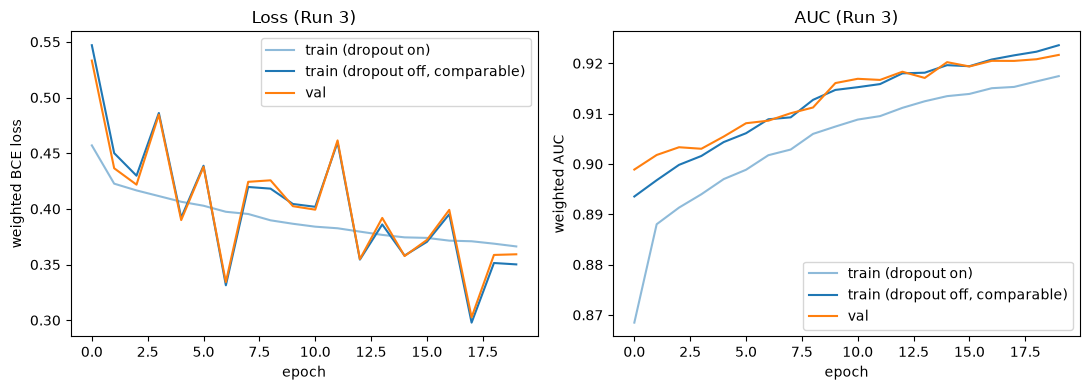

Final weighted val AUC (Run 3) = 0.9217


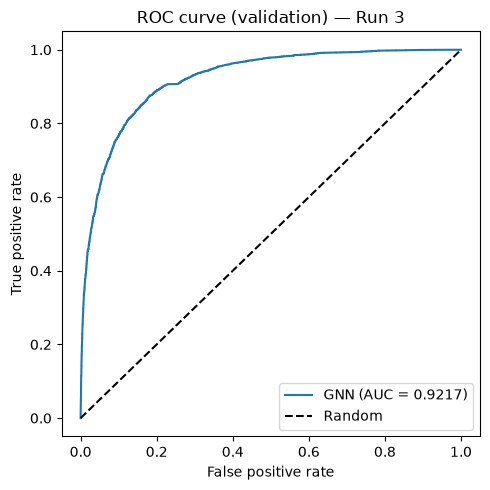

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(history_run3["train_loss"], label="train (dropout on)", color="tab:blue", alpha=0.5)
axes[0].plot(history_run3["train_loss_eval"], label="train (dropout off, comparable)", color="tab:blue")
axes[0].plot(history_run3["val_loss"], label="val", color="tab:orange")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("weighted BCE loss")
axes[0].set_title("Loss (Run 3)")
axes[0].legend()

axes[1].plot(history_run3["train_auc"], label="train (dropout on)", color="tab:blue", alpha=0.5)
axes[1].plot(history_run3["train_auc_eval"], label="train (dropout off, comparable)", color="tab:blue")
axes[1].plot(history_run3["val_auc"], label="val", color="tab:orange")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("weighted AUC")
axes[1].set_title("AUC (Run 3)")
axes[1].legend()

plt.tight_layout()
plt.show()

model_run3.eval()
all_y, all_p, all_w = [], [], []
with torch.no_grad():
    for batch in val_loader_run3:
        batch = batch.to(DEVICE)
        probs = torch.sigmoid(model_run3(batch.x, batch.edge_index, batch.batch))
        all_y.append(batch.y.cpu().numpy())
        all_p.append(probs.cpu().numpy())
        all_w.append(batch.w.cpu().numpy())

y_val_scores_run3 = np.concatenate(all_p)
y_val_run3 = np.concatenate(all_y)
w_val_run3 = np.concatenate(all_w)

auc_val_run3 = roc_auc_score(y_val_run3, y_val_scores_run3, sample_weight=w_val_run3)
print(f"Final weighted val AUC (Run 3) = {auc_val_run3:.4f}")

fpr_run3, tpr_run3, _ = roc_curve(y_val_run3, y_val_scores_run3, sample_weight=w_val_run3)
plt.figure(figsize=(5, 5))
plt.plot(fpr_run3, tpr_run3, label=f"GNN (AUC = {auc_val_run3:.4f})")
plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC curve (validation) — Run 3")
plt.legend()
plt.tight_layout()
plt.show()

## Feature Importance (Permutation) — Run 3

Reuses `permutation_importance_gnn`/`score_node_features`/
`plot_importance_bar` from the Run 2 section unchanged.

Baseline weighted val AUC: 0.9217


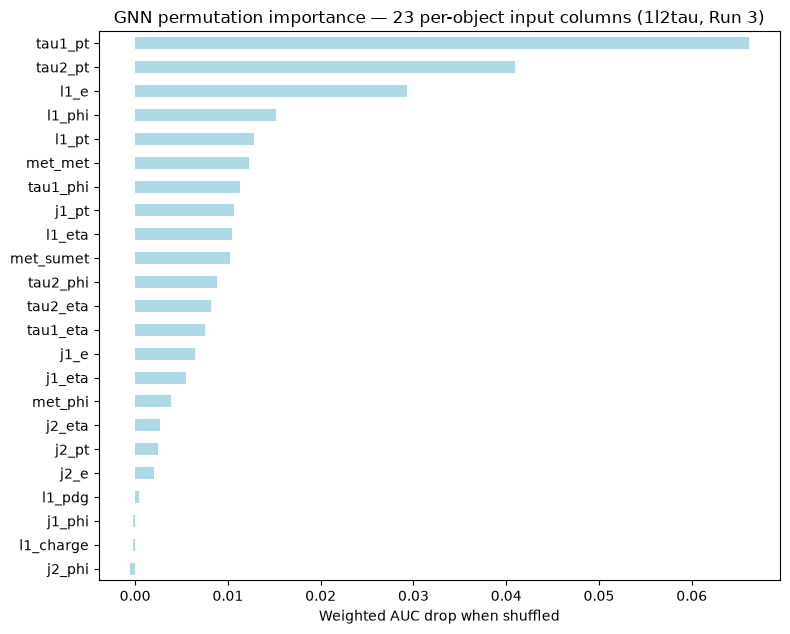

tau1_pt      0.066173
tau2_pt      0.040992
l1_e         0.029332
l1_phi       0.015234
l1_pt        0.012834
met_met      0.012225
tau1_phi     0.011262
j1_pt        0.010624
l1_eta       0.010468
met_sumet    0.010224
tau2_phi     0.008840
tau2_eta     0.008227
tau1_eta     0.007569
j1_e         0.006488
j1_eta       0.005462
met_phi      0.003814
j2_eta       0.002706
j2_pt        0.002433
j2_e         0.002043
l1_pdg       0.000454
j1_phi      -0.000189
l1_charge   -0.000191
j2_phi      -0.000586
Name: auc_drop, dtype: float64

In [24]:
importance_run3 = permutation_importance_gnn(
    model_run3, val_scaled_run3, val_imp_run3, y_val_run3, w_val_run3, REQUIRED_OBJECT_COLUMNS, n_repeats=5,
)
plot_importance_bar(
    importance_run3, top_n=30,
    title=f"GNN permutation importance — {len(REQUIRED_OBJECT_COLUMNS)} per-object input columns (1l2tau, Run 3)",
)
importance_run3

## Physics Figure of Merit & Held-Out Test Evaluation — Run 3

Reuses `significance_scan` from the Run 2 section. The score cut is selected
by scanning Run 3's own VAL only, then applied frozen to Run 3's own
never-before-seen TEST partition, scored exactly once.

In [25]:
w_val_signed_run3 = val_df_run3["w_phys"].to_numpy()
z_val_run3, thr_val_run3 = significance_scan(y_val_run3, y_val_scores_run3, w_val_signed_run3)

print(f"Weighted val AUC (Run 3) = {auc_val_run3:.4f}")
print(f"Max Asimov Z (val, Run 3) = {z_val_run3:.3f} at score cut = {thr_val_run3:.4f}")

# ---- HELD-OUT TEST EVALUATION (Run 3) - scored EXACTLY ONCE ----------------
# test_dataset_run3/test_loader_run3 have not participated in anything above
# (not the imputation/scaler fit, not training, not early stopping, not the
# significance-scan cut selection just above). The cut `thr_val_run3` was
# chosen on Run 3 VAL only; it is applied here FROZEN, NOT re-scanned on test.

model_run3.eval()
all_y, all_p, all_w = [], [], []
with torch.no_grad():
    for batch in test_loader_run3:
        batch = batch.to(DEVICE)
        probs = torch.sigmoid(model_run3(batch.x, batch.edge_index, batch.batch))
        all_y.append(batch.y.cpu().numpy())
        all_p.append(probs.cpu().numpy())
        all_w.append(batch.w.cpu().numpy())

test_scores_run3 = np.concatenate(all_p)
y_test_run3 = np.concatenate(all_y)
w_test_abs_run3 = np.concatenate(all_w)
w_test_signed_run3 = test_df_run3["w_phys"].to_numpy()

auc_test_run3 = roc_auc_score(y_test_run3, test_scores_run3, sample_weight=w_test_abs_run3)

S_test_run3 = w_test_signed_run3[(test_scores_run3 >= thr_val_run3) & (y_test_run3 == 1)].sum()
B_test_run3 = w_test_signed_run3[(test_scores_run3 >= thr_val_run3) & (y_test_run3 == 0)].sum()
z_test_run3 = (np.sqrt(2 * ((S_test_run3 + B_test_run3) * np.log(1 + S_test_run3 / B_test_run3) - S_test_run3))
               if (S_test_run3 > 0 and B_test_run3 > 0) else np.nan)

print(f"\nWeighted AUC (Run 3): val = {auc_val_run3:.4f}  |  test (held-out, scored once) = {auc_test_run3:.4f}")
print(f"At the VAL-selected score cut = {thr_val_run3:.4f} (frozen, NOT re-scanned on test):")
print(f"  test S = {S_test_run3:.2f} | test B = {B_test_run3:.2f} | test Z = {z_test_run3:.3f}  (val Z was {z_val_run3:.3f})")

Weighted val AUC (Run 3) = 0.9217
Max Asimov Z (val, Run 3) = 0.015 at score cut = 0.9069



Weighted AUC (Run 3): val = 0.9217  |  test (held-out, scored once) = 0.9213
At the VAL-selected score cut = 0.9069 (frozen, NOT re-scanned on test):
  test S = 0.07 | test B = 19.83 | test Z = 0.015  (val Z was 0.015)


## Sanity Checks & Summary — Run 3

In [26]:
# ---- Determinism check, same acceptance criterion as the Run 2 section:
# re-seeding immediately before each of two short training runs should give
# an EXACT match.

set_seed(RANDOM_STATE)
_, _, det_check_a_run3, _, _ = train_model(
    hidden_channels=16, n_epochs=5, patience=5, verbose=False,
    train_loader_fit_data=train_loader_fit_run3, train_loader_eval_data=train_loader_eval_run3,
    val_loader_data=val_loader_run3,
)

set_seed(RANDOM_STATE)
_, _, det_check_b_run3, _, _ = train_model(
    hidden_channels=16, n_epochs=5, patience=5, verbose=False,
    train_loader_fit_data=train_loader_fit_run3, train_loader_eval_data=train_loader_eval_run3,
    val_loader_data=val_loader_run3,
)
assert det_check_a_run3 == det_check_b_run3, f"Determinism check FAILED (Run 3): {det_check_a_run3} != {det_check_b_run3}"

print(f"Determinism check passed (Run 3): two re-seeded runs give identical val_auc = {det_check_a_run3:.6f}")

# ---- Final summary ----------------------------------------------------------

summary_run3 = pd.DataFrame([{
    "model": f"GNN (object nodes, {N_NODES} nodes/event)",
    "val_auc": auc_val_run3,
    "max_asimov_Z (val)": z_val_run3,
    "test_auc (held-out, scored once)": auc_test_run3,
    "test_Z_at_val_cut (held-out)": z_test_run3,
}])

print("\nFinal summary (GNN, 1l2tau Run 3):")
print(summary_run3.to_string(index=False))
summary_run3

Determinism check passed (Run 3): two re-seeded runs give identical val_auc = 0.901032

Final summary (GNN, 1l2tau Run 3):
                            model  val_auc  max_asimov_Z (val)  test_auc (held-out, scored once)  test_Z_at_val_cut (held-out)
GNN (object nodes, 6 nodes/event) 0.921664            0.014934                          0.921293                      0.015142


,model,val_auc,max_asimov_Z (val),"test_auc (held-out, scored once)",test_Z_at_val_cut (held-out)
0,"GNN (object nodes, 6 nodes/event)",0.921664,0.014934,0.921293,0.015142
